In [1]:
# Locate the repository when Jupyter starts in Notebooks/.
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'Notebooks': PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

from SRC.KingCRAB.reflectivity import load_reflectivity, make_interpolator, stitch_curves, geant_wavelength_table

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
#Data taken from https://www.edmundoptics.com/p/50mm-diameter-vacuum-uv-enhanced-mirror/3368/

MIRROR_670_JSON  = PROJECT_ROOT / "DATA/Mirror_Reflectivity_120_670.json"
MIRROR_2520_JSON = PROJECT_ROOT / "DATA/Mirror_Reflectivity_120_2520.json"

In [3]:
w1, R1 = load_reflectivity(MIRROR_670_JSON)
w2, R2 = load_reflectivity(MIRROR_2520_JSON)

w_merged, R_merged = stitch_curves(
    w1, R1, w2, R2,
    join=float(w1.max()),     
    blend_nm=30.0,           
    n=5000,
    interp_kind="pchip"       
)

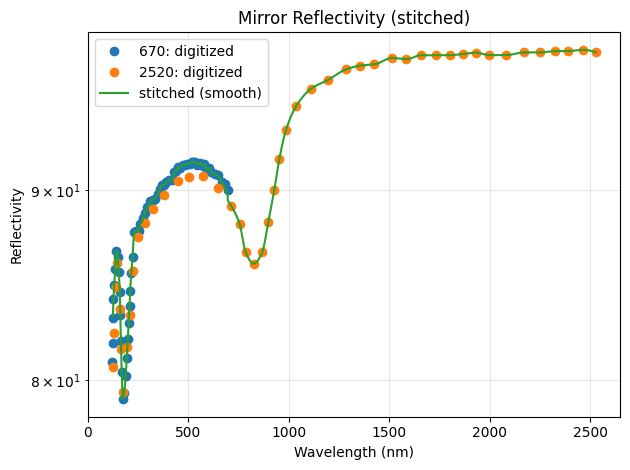

In [4]:
plt.figure()
plt.plot(w1, R1, "o", label="670: digitized")
plt.plot(w2, R2, "o", label="2520: digitized")
plt.plot(w_merged, R_merged, "-", label="stitched (smooth)")
plt.yscale("log")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectivity")
plt.title("Mirror Reflectivity (stitched)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

In [6]:
geant_wavelength_table(w_merged, R_merged, max_points=40)

(array([ 124.24778761,  185.80884318,  247.36989876,  308.93095433,
         370.49200991,  432.05306548,  494.0950668 ,  555.65612237,
         617.21717795,  678.77823352,  740.3392891 ,  801.90034467,
         863.94234599,  925.50340157,  987.06445714, 1048.62551271,
        1110.18656829, 1172.22856961, 1233.78962518, 1295.35068076,
        1356.91173633, 1418.4727919 , 1480.03384748, 1542.0758488 ,
        1603.63690437, 1665.19795995, 1726.75901552, 1788.32007109,
        1850.36207241, 1911.92312799, 1973.48418356, 2035.04523914,
        2096.60629471, 2158.16735028, 2220.2093516 , 2281.77040718,
        2343.33146275, 2404.89251833, 2466.4535739 , 2528.49557522]),
 array([0.83229028, 0.79959186, 0.87777888, 0.89328979, 0.90318895,
        0.91043701, 0.91510092, 0.91537345, 0.91020804, 0.90243146,
        0.8857071 , 0.86231373, 0.86524079, 0.89902975, 0.93493478,
        0.95064882, 0.95872721, 0.96265207, 0.96693086, 0.97079647,
        0.97265708, 0.97331575, 0.97612196, 0.